# Clasificación MDD/HC con Machine Learning Clásico

En este notebook evaluamos tres clasificadores clásicos **SVM**, **Random Forest** y **XGBoost** sobre 14 experimentos de features derivadas de datos fMRI del dataset REST-meta-MDD.

El objetivo es identificar qué combinación de estrategia de reducción de dimensionalidad, tipo de feature e harmonización ComBat produce el mejor AUC-ROC.

## Índice
1. [Imports y carga de metricas](#1)
2. [Experimentos de features](#2)
3. [Resultados por modelo](#3)
4. [Comparación global y Heatmap de AUC-ROC](#4)
5. [Efecto del ComBat](#5)
6. [Mejor modelo](#6)
7. [Ranking final](#7)
8. [Conclusiones](#8)

## 1. Imports y carga de métricas <a id='1'></a>

In [2]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

METRICS_DIR = '../results/metrics'
FIGURES_DIR = '../results/figures'

EXPERIMENTOS = [
    'fc', 'alff', 'combined',
    'fc_anova', 'combined_anova',
    'fc_mrmr', 'combined_mrmr',
    'fc_combat', 'alff_combat', 'combined_combat',
    'fc_anova_combat', 'combined_anova_combat',
    'fc_mrmr_combat', 'combined_mrmr_combat',
]

MODELOS = {
    'SVM': ('svm', 'SVM'),
    'RF':  ('rf',  'RF'),
    'XGB': ('xgb', 'XGB'),
}

def cargar_metricas(subdir: str, prefijo: str, experimento: str) -> dict:
    """Carga métricas de test desde JSON.

    Args:
        subdir: Subdirectorio del modelo (svm, rf, xgb).
        prefijo: Prefijo del archivo (SVM, RF, XGB).
        experimento: Nombre del experimento.

    Returns:
        Diccionario con métricas, o None si no existe el archivo.
    """
    path = os.path.join(METRICS_DIR, subdir, f'metrics_{prefijo}_{experimento}.json')
    if not os.path.exists(path):
        return None
    with open(path) as f:
        return json.load(f)

# construir dataframe con todas las métricas
registros = []
for nombre_modelo, (subdir, prefijo) in MODELOS.items():
    for exp in EXPERIMENTOS:
        m = cargar_metricas(subdir, prefijo, exp)
        if m:
            registros.append({
                'modelo': nombre_modelo,
                'experimento': exp,
                'accuracy':    round(m['accuracy'], 4),
                'sensitivity': round(m['sensitivity'], 4),
                'specificity': round(m['specificity'], 4),
                'precision':   round(m['precision'], 4),
                'f1_score':    round(m['f1_score'], 4),
                'auc_roc':     round(m['auc_roc'], 4),
            })

df = pd.DataFrame(registros)
print(f'Métricas cargadas: {len(df)} filas ({df["modelo"].nunique()} modelos × {df["experimento"].nunique()} experimentos)')

Métricas cargadas: 42 filas (3 modelos × 14 experimentos)


## 2. Experimentos de features <a id='2'></a>

El pipeline genera 14 variantes combinando tipo de feature, método de reducción de dimensionalidad y harmonización ComBat.

| Experimento | Features | Reducción | Dimensiones | ComBat |
|---|---|---|---|---|
| `fc` | Conectividad funcional (FC) | IncrementalPCA | 300 | No |
| `alff` | ALFF (Harvard-Oxford atlas) | StandardScaler | 49 | No |
| `combined` | FC + ALFF | PCA + Scale | 349 | No |
| `fc_anova` | FC | ANOVA SelectKBest | 500 | No |
| `combined_anova` | FC + ALFF | ANOVA + Scale | 549 | No |
| `fc_mrmr` | FC | ANOVA(5000) → mRMR | 500 | No |
| `combined_mrmr` | FC + ALFF | mRMR + Scale | 549 | No |
| `*_combat` | (igual) | (igual) | (igual) | Sí |

**Estrategias de reducción:**
- **PCA**: Captura la máxima varianza global. No usa etiquetas. Robusto al sobreajuste.
- **ANOVA SelectKBest**: Selecciona features con mayor discriminación entre MDD y HC. Usa etiquetas → puede sobreajustar si K es muy grande.
- **mRMR**: Maximiza relevancia con la etiqueta y minimiza redundancia entre features. Más selectivo que ANOVA.

## 3. Resultados por modelo <a id='3'></a>

### 3.1 SVM (Support Vector Machine)

In [3]:
df_svm = df[df['modelo'] == 'SVM'].set_index('experimento')
display(df_svm[['auc_roc', 'accuracy', 'sensitivity', 'specificity', 'f1_score']]
        .sort_values('auc_roc', ascending=False)
        .style.background_gradient(cmap='RdYlGn', subset=['auc_roc'])
        .format('{:.4f}'))

,auc_roc,accuracy,sensitivity,specificity,f1_score
experimento,,,,,
combined_combat,0.7392,0.6744,0.8152,0.5125,0.7282
combined,0.7051,0.6105,0.7283,0.4750,0.6667
alff_combat,0.6755,0.6279,0.6793,0.5687,0.6614
fc,0.6498,0.6076,0.7120,0.4875,0.6599
fc_combat,0.6480,0.6134,0.6848,0.5312,0.6545
alff,0.6294,0.5698,0.7826,0.3250,0.6606
combined_mrmr,0.6015,0.5814,0.6576,0.4938,0.6269
fc_mrmr,0.5973,0.5785,0.6467,0.5000,0.6214
combined_mrmr_combat,0.5880,0.5349,0.6033,0.4562,0.5812


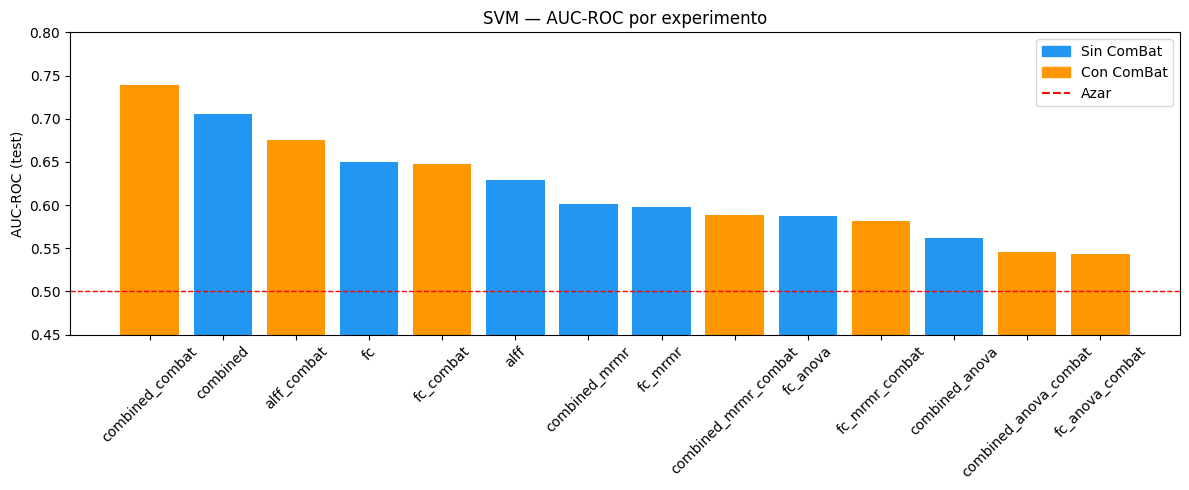

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
orden = df_svm['auc_roc'].sort_values(ascending=False).index
colores = ['#2196F3' if 'combat' not in e else '#FF9800' for e in orden]
ax.bar(orden, df_svm.loc[orden, 'auc_roc'], color=colores)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Azar (AUC=0.5)')
ax.set_ylim(0.45, 0.80)
ax.set_ylabel('AUC-ROC (test)')
ax.set_title('SVM — AUC-ROC por experimento')
ax.tick_params(axis='x', rotation=45)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#2196F3', label='Sin ComBat'),
    Patch(color='#FF9800', label='Con ComBat'),
    plt.Line2D([0], [0], color='red', linestyle='--', label='Azar'),
])
plt.tight_layout()
plt.show()

### 3.2 Random Forest

In [5]:
df_rf = df[df['modelo'] == 'RF'].set_index('experimento')
display(df_rf[['auc_roc', 'accuracy', 'sensitivity', 'specificity', 'f1_score']]
        .sort_values('auc_roc', ascending=False)
        .style.background_gradient(cmap='RdYlGn', subset=['auc_roc'])
        .format('{:.4f}'))

,auc_roc,accuracy,sensitivity,specificity,f1_score
experimento,,,,,
alff_combat,0.6804,0.6279,0.8043,0.4250,0.6981
combined_combat,0.6629,0.6192,0.8587,0.3438,0.7069
fc,0.6611,0.5901,0.8913,0.2437,0.6994
fc_combat,0.6592,0.5930,0.9076,0.2313,0.7046
alff,0.6510,0.6017,0.7174,0.4688,0.6584
combined,0.6105,0.5843,0.6848,0.4688,0.6380
combined_mrmr,0.5900,0.5465,0.6848,0.3875,0.6176
fc_mrmr,0.5878,0.5610,0.6957,0.4062,0.6290
fc_mrmr_combat,0.5758,0.5436,0.6196,0.4562,0.5922


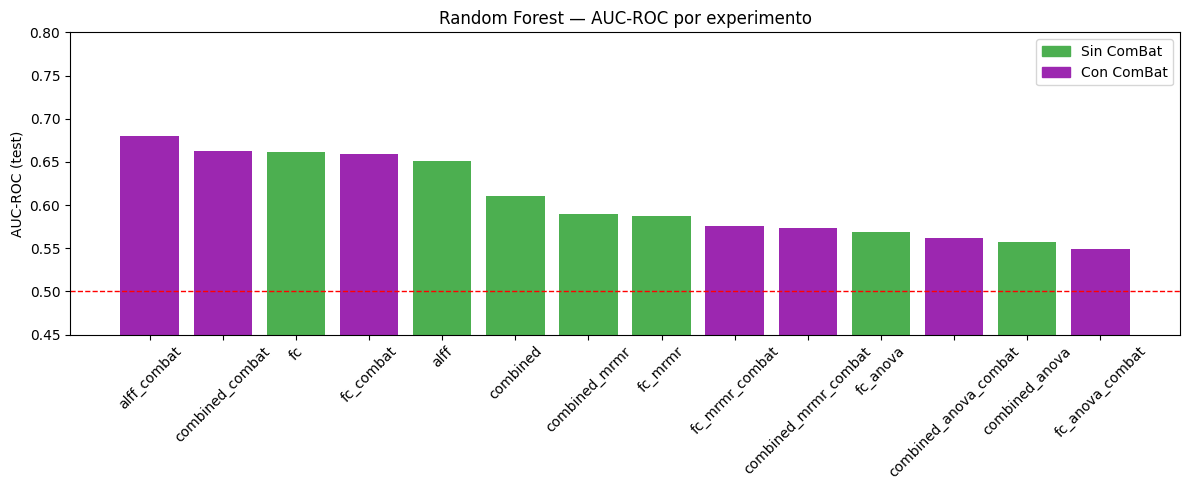

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
orden = df_rf['auc_roc'].sort_values(ascending=False).index
colores = ['#4CAF50' if 'combat' not in e else '#9C27B0' for e in orden]
ax.bar(orden, df_rf.loc[orden, 'auc_roc'], color=colores)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1)
ax.set_ylim(0.45, 0.80)
ax.set_ylabel('AUC-ROC (test)')
ax.set_title('Random Forest — AUC-ROC por experimento')
ax.tick_params(axis='x', rotation=45)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#4CAF50', label='Sin ComBat'),
    Patch(color='#9C27B0', label='Con ComBat'),
])
plt.tight_layout()
plt.show()

### 3.3 XGBoost

In [7]:
df_xgb = df[df['modelo'] == 'XGB'].set_index('experimento')
display(df_xgb[['auc_roc', 'accuracy', 'sensitivity', 'specificity', 'f1_score']]
        .sort_values('auc_roc', ascending=False)
        .style.background_gradient(cmap='RdYlGn', subset=['auc_roc'])
        .format('{:.4f}'))

,auc_roc,accuracy,sensitivity,specificity,f1_score
experimento,,,,,
combined_combat,0.6722,0.6047,0.7011,0.4938,0.6548
fc,0.6702,0.6250,0.7500,0.4813,0.6815
alff_combat,0.6636,0.6221,0.7011,0.5312,0.6649
combined,0.6575,0.5959,0.6957,0.4813,0.6481
alff,0.6494,0.6134,0.6576,0.5625,0.6453
fc_combat,0.6329,0.6279,0.7609,0.4750,0.6863
combined_mrmr_combat,0.6043,0.5698,0.6196,0.5125,0.6064
fc_mrmr,0.6008,0.5669,0.6196,0.5062,0.6048
combined_mrmr,0.5983,0.5698,0.6250,0.5062,0.6085


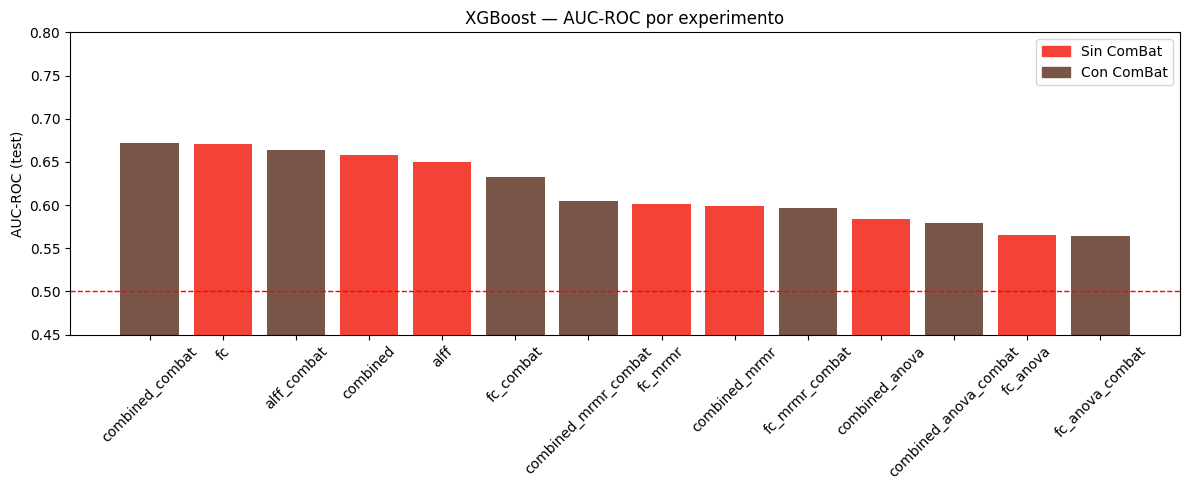

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
orden = df_xgb['auc_roc'].sort_values(ascending=False).index
colores = ['#F44336' if 'combat' not in e else '#795548' for e in orden]
ax.bar(orden, df_xgb.loc[orden, 'auc_roc'], color=colores)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1)
ax.set_ylim(0.45, 0.80)
ax.set_ylabel('AUC-ROC (test)')
ax.set_title('XGBoost — AUC-ROC por experimento')
ax.tick_params(axis='x', rotation=45)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#F44336', label='Sin ComBat'),
    Patch(color='#795548', label='Con ComBat'),
])
plt.tight_layout()
plt.show()

## 4. Comparación global y Heatmap de AUC-ROC <a id='4'></a>

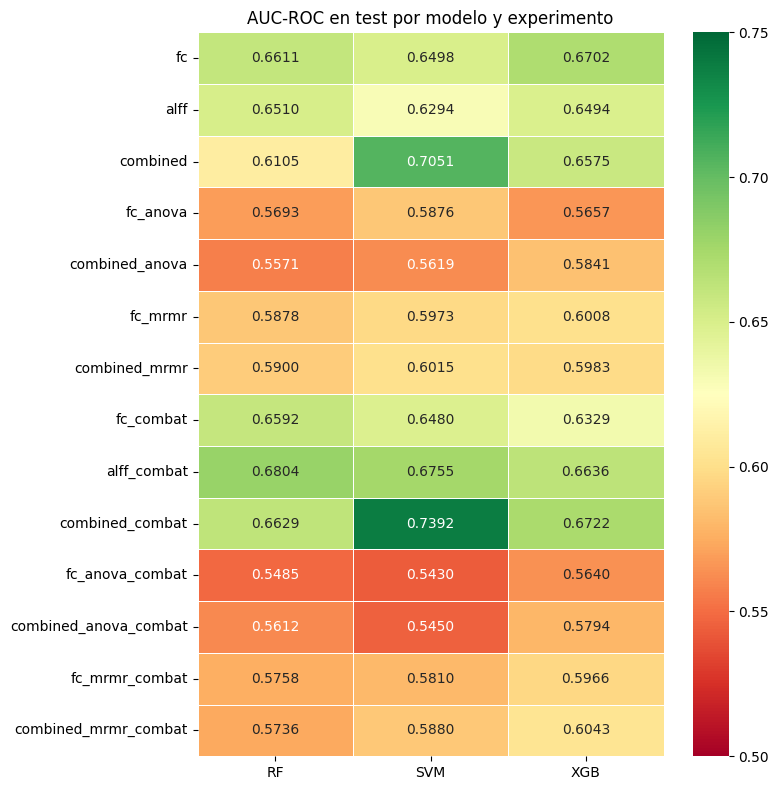

Mejor resultado: SVM — combined_combat — AUC=0.7392


In [9]:
# pivot: filas = experimento, columnas = modelo
df_pivot = df.pivot(index='experimento', columns='modelo', values='auc_roc')
df_pivot = df_pivot.loc[EXPERIMENTOS]  # orden fijo

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(
    df_pivot,
    annot=True, fmt='.4f',
    cmap='RdYlGn',
    vmin=0.50, vmax=0.75,
    linewidths=0.5,
    ax=ax
)
ax.set_title('AUC-ROC en test por modelo y experimento')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# mejor resultado global
idx = df['auc_roc'].idxmax()
mejor = df.loc[idx]
print(f'Mejor resultado: {mejor["modelo"]} — {mejor["experimento"]} — AUC={mejor["auc_roc"]:.4f}')

## 5. Efecto del ComBat <a id='5'></a>

ComBat es un método de harmonización que elimina el efecto de sitio (scanner bias). Comparamos el AUC con y sin ComBat para cada experimento base.

In [10]:
EXPERIMENTOS_BASE = ['fc', 'alff', 'combined', 'fc_anova', 'combined_anova', 'fc_mrmr', 'combined_mrmr']

filas = []
for modelo in ['SVM', 'RF', 'XGB']:
    df_m = df[df['modelo'] == modelo].set_index('experimento')
    for base in EXPERIMENTOS_BASE:
        combat = base + '_combat'
        if base in df_m.index and combat in df_m.index:
            auc_base   = df_m.loc[base,   'auc_roc']
            auc_combat = df_m.loc[combat, 'auc_roc']
            delta = auc_combat - auc_base
            filas.append({
                'modelo': modelo,
                'experimento': base,
                'AUC sin ComBat': auc_base,
                'AUC con ComBat': auc_combat,
                'Δ AUC': round(delta, 4),
            })

df_combat = pd.DataFrame(filas)

def colorear_delta(val):
    color = 'green' if val > 0 else ('red' if val < 0 else 'black')
    return f'color: {color}'

display(df_combat.style
        .applymap(colorear_delta, subset=['Δ AUC'])
        .format('{:.4f}', subset=['AUC sin ComBat', 'AUC con ComBat', 'Δ AUC']))

C:\Users\basti\AppData\Local\Temp\ipykernel_14000\3081827218.py:27: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(colorear_delta, subset=['Δ AUC'])


,modelo,experimento,AUC sin ComBat,AUC con ComBat,Δ AUC
0,SVM,fc,0.6498,0.6480,-0.0018
1,SVM,alff,0.6294,0.6755,0.0461
2,SVM,combined,0.7051,0.7392,0.0341
3,SVM,fc_anova,0.5876,0.5430,-0.0446
4,SVM,combined_anova,0.5619,0.5450,-0.0169
5,SVM,fc_mrmr,0.5973,0.5810,-0.0163
6,SVM,combined_mrmr,0.6015,0.5880,-0.0135
7,RF,fc,0.6611,0.6592,-0.0019
8,RF,alff,0.6510,0.6804,0.0294
9,RF,combined,0.6105,0.6629,0.0524


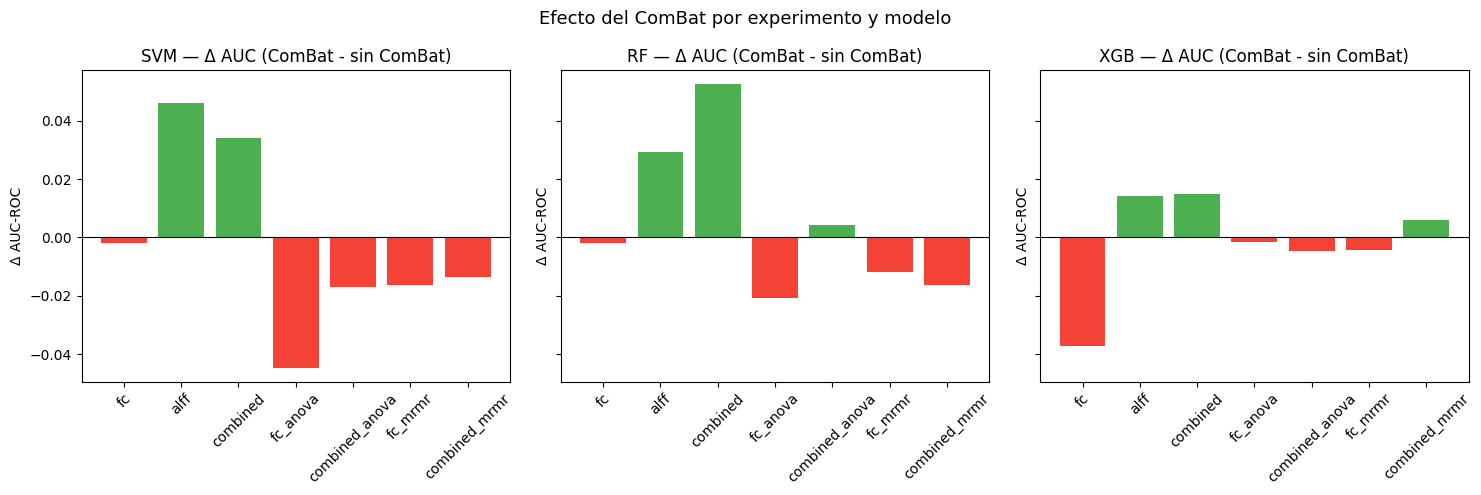

In [11]:
# gráfica de delta por experimento, agrupado por modelo
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, modelo in zip(axes, ['SVM', 'RF', 'XGB']):
    sub = df_combat[df_combat['modelo'] == modelo]
    colores = ['#4CAF50' if d > 0 else '#F44336' for d in sub['Δ AUC']]
    ax.bar(sub['experimento'], sub['Δ AUC'], color=colores)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'{modelo} — Δ AUC (ComBat - sin ComBat)')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel('Δ AUC-ROC')

plt.suptitle('Efecto del ComBat por experimento y modelo', fontsize=13)
plt.tight_layout()
plt.show()

**Interpretación:**

- ComBat **mejora** los experimentos basados en PCA (`fc`, `combined`). Al eliminar el efecto de sitio, PCA puede capturar varianza clínica real en lugar de varianza técnica entre scanners.
- ComBat **perjudica o no ayuda** a los experimentos con ANOVA y mRMR. Estos métodos de selección supervisada dependen de diferencias entre grupos MDD/HC, pero parte de esa señal viene correlacionada con el sitio. Cuando ComBat la elimina, la selección pierde discriminación.
- `alff` mejora levemente con ComBat porque las diferencias de ALFF entre sitios son principalmente ruido de scanner.

## 6. Mejor modelo: SVM `combined_combat` <a id='6'></a>

El mejor resultado global es **SVM con features `combined_combat`** (FC-PCA + ALFF + ComBat), con **AUC-ROC = 0.7392** en test.

In [12]:
# métricas detalladas del mejor modelo
mejor_exp = 'combined_combat'
m = cargar_metricas('svm', 'SVM', mejor_exp)

print('Métricas en test — SVM combined_combat')
print(f'  AUC-ROC:     {m["auc_roc"]:.4f}')
print(f'  Accuracy:    {m["accuracy"]:.4f}')
print(f'  Sensitivity: {m["sensitivity"]:.4f}  (recall para MDD)')
print(f'  Specificity: {m["specificity"]:.4f}  (recall para HC)')
print(f'  Precision:   {m["precision"]:.4f}')
print(f'  F1-score:    {m["f1_score"]:.4f}')
cm = m['confusion_matrix']
print(f'  Matriz de confusión: TP={cm["TP"]}, FP={cm["FP"]}, TN={cm["TN"]}, FN={cm["FN"]}')

Métricas en test — SVM combined_combat
  AUC-ROC:     0.7392
  Accuracy:    0.6744
  Sensitivity: 0.8152  (recall para MDD)
  Specificity: 0.5125  (recall para HC)
  Precision:   0.6579
  F1-score:    0.7282
  Matriz de confusión: TP=150, FP=78, TN=82, FN=34


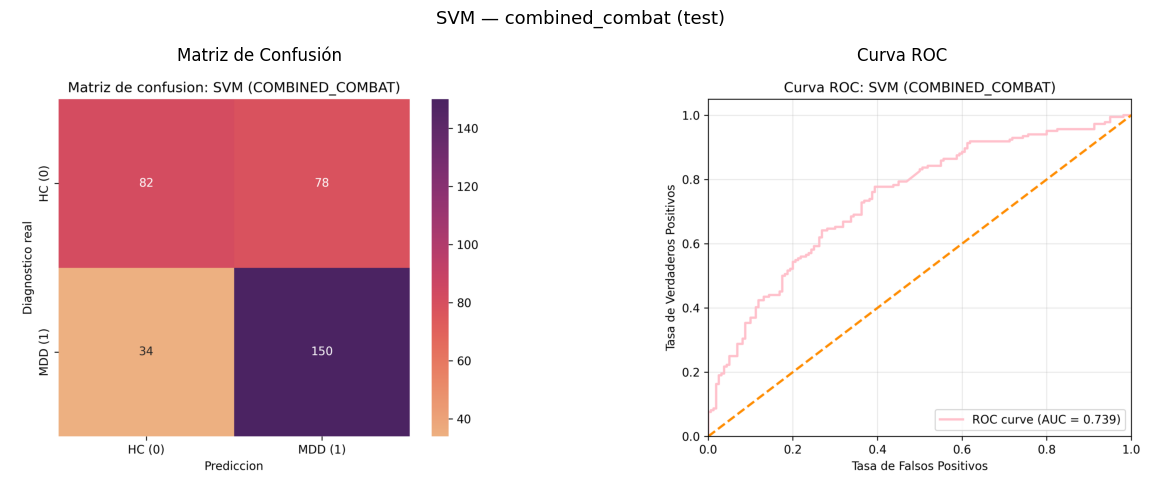

In [13]:
# mostrar confusion matrix y ROC curve guardados
cm_path  = f'../results/figures/svm/cm_SVM_{mejor_exp}.png'
roc_path = f'../results/figures/svm/roc_SVM_{mejor_exp}.png'

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].imshow(mpimg.imread(cm_path))
axes[0].axis('off')
axes[0].set_title('Matriz de Confusión')

axes[1].imshow(mpimg.imread(roc_path))
axes[1].axis('off')
axes[1].set_title('Curva ROC')

plt.suptitle('SVM — combined_combat (test)', fontsize=13)
plt.tight_layout()
plt.show()

**Análisis del mejor modelo:**

- **Sensitivity = 0.815**: El modelo detecta el 81.5% de los pacientes con MDD. En clínica, esto es deseable: se prefiere detectar la mayoría de los enfermos aunque haya algunos falsos positivos.
- **Specificity = 0.513**: El modelo clasifica correctamente solo el 51.3% de los sujetos sanos (HC), lo que produce un número elevado de falsos positivos (FP=78). Hay una tensión clásica entre sensibilidad y especificidad.
- **AUC = 0.739**: Indica discriminación moderada. Un clasificador perfecto tendría AUC=1.0, uno aleatorio AUC=0.5.
- El umbral de decisión predeterminado (0.5) no es necesariamente óptimo. En la curva ROC se puede seleccionar un umbral distinto según la prioridad clínica.

## 7. Ranking final <a id='7'></a>

In [14]:
# top 10 combinaciones modelo-experimento
top10 = (df.sort_values('auc_roc', ascending=False)
           .head(10)
           .reset_index(drop=True))
top10.index += 1

display(top10[['modelo', 'experimento', 'auc_roc', 'accuracy', 'sensitivity', 'specificity', 'f1_score']]
        .style.background_gradient(cmap='RdYlGn', subset=['auc_roc'])
        .format('{:.4f}', subset=['auc_roc', 'accuracy', 'sensitivity', 'specificity', 'f1_score']))

,modelo,experimento,auc_roc,accuracy,sensitivity,specificity,f1_score
1,SVM,combined_combat,0.7392,0.6744,0.8152,0.5125,0.7282
2,SVM,combined,0.7051,0.6105,0.7283,0.4750,0.6667
3,RF,alff_combat,0.6804,0.6279,0.8043,0.4250,0.6981
4,SVM,alff_combat,0.6755,0.6279,0.6793,0.5687,0.6614
5,XGB,combined_combat,0.6722,0.6047,0.7011,0.4938,0.6548
6,XGB,fc,0.6702,0.6250,0.7500,0.4813,0.6815
7,XGB,alff_combat,0.6636,0.6221,0.7011,0.5312,0.6649
8,RF,combined_combat,0.6629,0.6192,0.8587,0.3438,0.7069
9,RF,fc,0.6611,0.5901,0.8913,0.2437,0.6994
10,RF,fc_combat,0.6592,0.5930,0.9076,0.2313,0.7046


## 8. Conclusiones <a id='8'></a>

**1. La mejor combinación es SVM + PCA + ComBat (`combined_combat`, AUC=0.739).**  
FC y ALFF juntos aportan más información que cada feature por separado. PCA permite comprimir las 1,679,028 features de conectividad funcional de forma no supervisada, evitando sobreajuste. ComBat elimina la varianza técnica entre los 25 sitios, mejorando la generalización.

**2. ANOVA y mRMR no superan a PCA en este dataset.**  
Aunque seleccionan features más discriminativas en entrenamiento, la selección supervisada captura correlaciones con el efecto de sitio. Cuando ComBat las elimina, la selección pierde poder y los resultados empeoran. Sin ComBat, el sobreajuste es el problema dominante.

**3. El AUC máximo (~0.74) es modesto pero esperable en neuroimagen clínica.**  
La heterogeneidad diagnóstica del MDD (múltiples subtipos, diferencias por medicación, edad, sexo) y el efecto de sitio residual limitan la discriminación. Resultados similares aparecen en la literatura para clasificadores clásicos sobre FC.

**4. Random Forest y XGBoost son competitivos pero no superan al SVM.**  
En espacios de alta dimensión con pocos sujetos (~1,600), el margen máximo del SVM tiene ventaja estructural sobre métodos basados en árboles.

**5. El modelo tiene alta sensibilidad (0.815) a expensas de baja especificidad (0.513).**  
El desbalance leve entre MDD y HC (857 vs 748 en train) y el umbral predeterminado favorecen la clase positiva. Ajustar el umbral o usar `class_weight` podría balancear el tradeoff según la aplicación clínica.